# Problema: Dataset de pingüinos: Este problema es entregable

Carga el sigiuente dataset y responde las siguientes preguntas:

```python
import pandas as pd
import seaborn as sns

# Cargar el dataset
df = sns.load_dataset('penguins')
```
Estas preguntas los guiarán a realizar un análisis descriptivo del dataset y a realizar un test de hipótesis.


In [76]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Cargar el dataset
df = sns.load_dataset('penguins')

penguin_palette = {
    "Adelie": "#fc7b1f",   
    "Gentoo": "#207074", 
    "Chinstrap": "#c55bca"    
}

sex_pallete = {
    "Male": "#1f77b4",    # azul
    "Female": "#ff69b4",  # rosa
    None: "#cccccc"       # gris para valores faltantes
}


# Problema: Dataset de pingüinos: Este problema es entregable

Carga el sigiuente dataset y responde las siguientes preguntas:

```python
import pandas as pd
import seaborn as sns

# Cargar el dataset
df = sns.load_dataset('penguins')
```
Estas preguntas los guiarán a realizar un análisis descriptivo del dataset y a realizar un test de hipótesis.


## Primera aproximación a los datos de forma general y su limpieza:

1. ¿Cuántas especies diferentes de pingüinos hay en el dataset? ¿Qué características de los pingüinos se dan para cada especie?

En el conjunto de datos se tienen 344 datos de **3 especies** de pingüinos:  

- **Adelie**  
- **Chinstrap**  
- **Gentoo**

<p align="left">
  <img src="https://allisonhorst.github.io/palmerpenguins/reference/figures/lter_penguins.png" 
       alt="Especies de pingüinos" 
       width="400"/>
</p>

Para cada pingüino se recopilan los siguientes datos:  

| Variable                | Descripción                                 |
|-------------------------|---------------------------------------------|
| **Island (isla)**       | Isla de procedencia del pingüino            |
| **Bill length (bill_length_mm)**  | Longitud del pico (en mm)              |
| **Bill depth (bill_depth_mm)**    | Profundidad del pico (en mm)           |
| **Flipper length (flipper_length_mm)** | Longitud de la aleta (en mm)         |
| **Body mass (body_mass_g)**       | Masa corporal (en gramos)              |
| **Sex (sexo)**          | Macho o hembra                              |

<p align="left">
  <img src="https://www.allaboutbirds.org/news/wp-content/uploads/2022/06/BlueJay_Avonet_bill-1280x542.jpg" 
       alt="Ejemplo de pico de ave" 
       width="400"/>
</p>


In [77]:
df['species'].unique(), df.shape[0]

(array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object), 344)

In [78]:
df.dtypes

species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

2. ¿Hay valores faltantes en las variables? Determine una estrategie de limpieza y apliquela.

- La columna sexo tiene 11 datos faltantes, los cuales podrían ser fácilmente eliminados ya que no corresponde a una cantidad significativa de datos

In [79]:
(df.isnull().sum() / len(df)) * 100

species              0.000000
island               0.000000
bill_length_mm       0.581395
bill_depth_mm        0.581395
flipper_length_mm    0.581395
body_mass_g          0.581395
sex                  3.197674
dtype: float64

In [80]:
# df.dropna(subset=['sex'], inplace=True)
df.dropna(inplace=True)

3. ¿Cuál es la isla con mayor número de pingüinos en el dataset? ¿Hay un desbalance en número en el número de pinguinos por isla? 
- La isla con mayor número de pingüinos en el dataset es Biscoe, con 163 individuos. Le siguen Dream con 123 y Torgersen con 47. Esto muestra que hay un desbalance en el número de pingüinos por isla, siendo Biscoe la isla con la mayor cantidad de registros.

In [81]:
df.groupby('island').size()

island
Biscoe       163
Dream        123
Torgersen     47
dtype: int64

4. Repita la pregunta anterior observando las especies.
- La especie con mayor número de pingüinos en el dataset es Adelie, con 146 individuos. Le siguen Gentoo con 119 y Chinstrap con 68. Esto muestra que hay un desbalance en el número de pingüinos por especie, siendo Adelie la especie con la mayor cantidad de registros.

In [82]:
df.groupby('species').size()

species
Adelie       146
Chinstrap     68
Gentoo       119
dtype: int64

## Tendencias y visualizacion de las variables




5. ¿Cuál es la longitud media y la desviacion estandard del tamaño del pico de los pingüinos por especie?

- La longitud media y la desviación estándar del tamaño del pico varían según la especie. La especie Adelie tiene una longitud media de 38.79 mm y una desviación estándar de 2.66 mm. La especie Chinstrap tiene una longitud media de 48.83 mm y una desviación estándar de 3.34 mm. La especie Gentoo tiene una longitud media de 47.50 mm y una desviación estándar de 3.08 mm. Esto muestra que Chinstrap y Gentoo tienen picos más largos en promedio que Adelie, y que la variabilidad dentro de cada especie es relativamente baja.




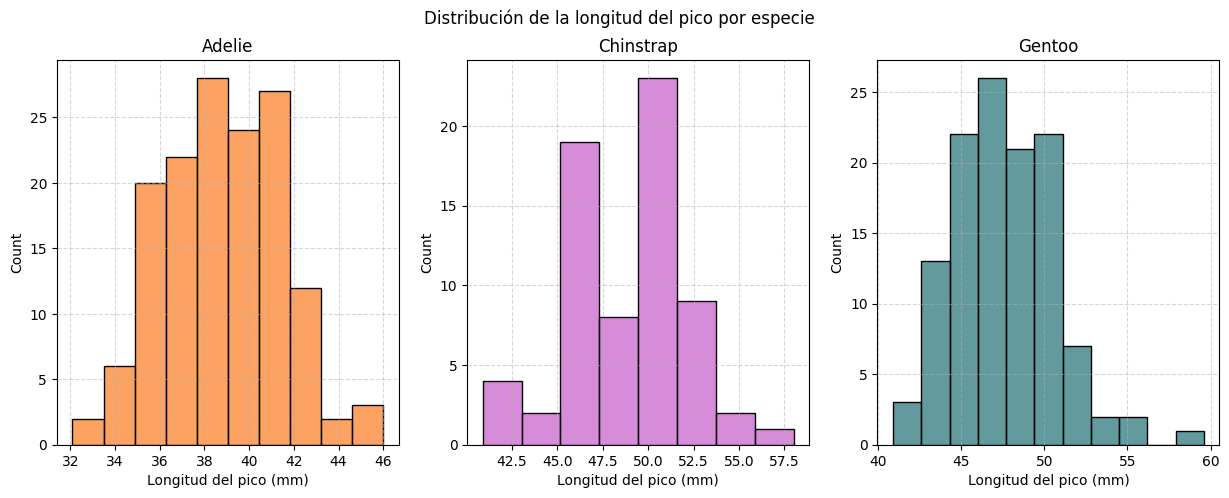

In [83]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i in range(len(df['species'].unique())):

    specie = df['species'].unique()[i]
    
    sns.histplot(data=df[df['species'] == specie], x='bill_length_mm', ax=axes[i], color=penguin_palette[specie], alpha=0.7)
    axes[i].set_title(f'{specie}')
    axes[i].set_xlabel('Longitud del pico (mm)')
    axes[i].grid(True, alpha=0.5, linestyle='--')
plt.suptitle('Distribución de la longitud del pico por especie')
plt.show()

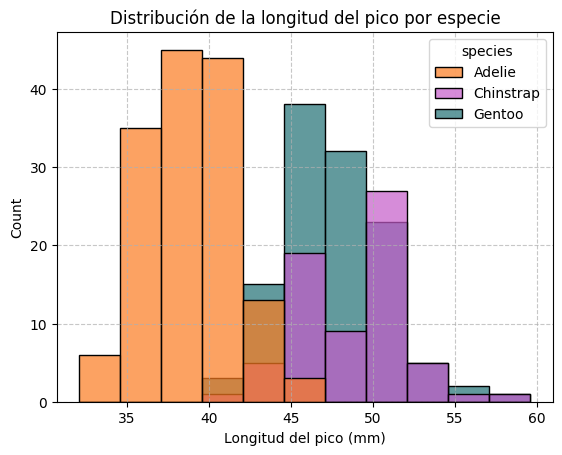

In [84]:
sns.histplot(data=df, x='bill_length_mm', hue='species', palette=penguin_palette, alpha=0.7)
plt.grid(True, alpha=0.7, linestyle='--')
plt.xlabel('Longitud del pico (mm)')
plt.title('Distribución de la longitud del pico por especie')
plt.show()

In [85]:
df.groupby('species')['bill_length_mm'].agg(['mean', 'std'])

,mean,std
species,,
Adelie,38.823973,2.662597
Chinstrap,48.833824,3.339256
Gentoo,47.568067,3.106116


6. ¿Qué pingüino tiene el pico más largo en el dataset y cuál es su especie?
- El pinguino con el pico más largo (59.6 mm) corresponde al registro 253 y su especie es Gentoo

In [86]:
df[df['bill_length_mm'] == df['bill_length_mm'].max()]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
253,Gentoo,Biscoe,59.6,17.0,230.0,6050.0,Male


7. ¿Como es la distribución de la masa corporal entre las especies de pingüinos?

La distribución de la masa corporal entre las especies de pingüinos muestra diferencias claras:

- **Adelie**: La masa corporal se distribuye aproximadamente de manera simétrica, con la mayoría de los valores entre 3,000 y 4,000 gramos.
- **Chinstrap**: La distribución también es simétrica, pero los valores de masa corporal son ligeramente menores que los de Adelie, concentrándose entre 3,000 y 4,000 gramos.
- **Gentoo**: Los pingüinos Gentoo presentan masas corporales mayores, con la mayoría de los valores entre 4,000 y 6,000 gramos.

En resumen, los Gentoo son los más pesados, seguidos por Adelie y luego Chinstrap. Las distribuciones son aproximadamente normales para cada especie.


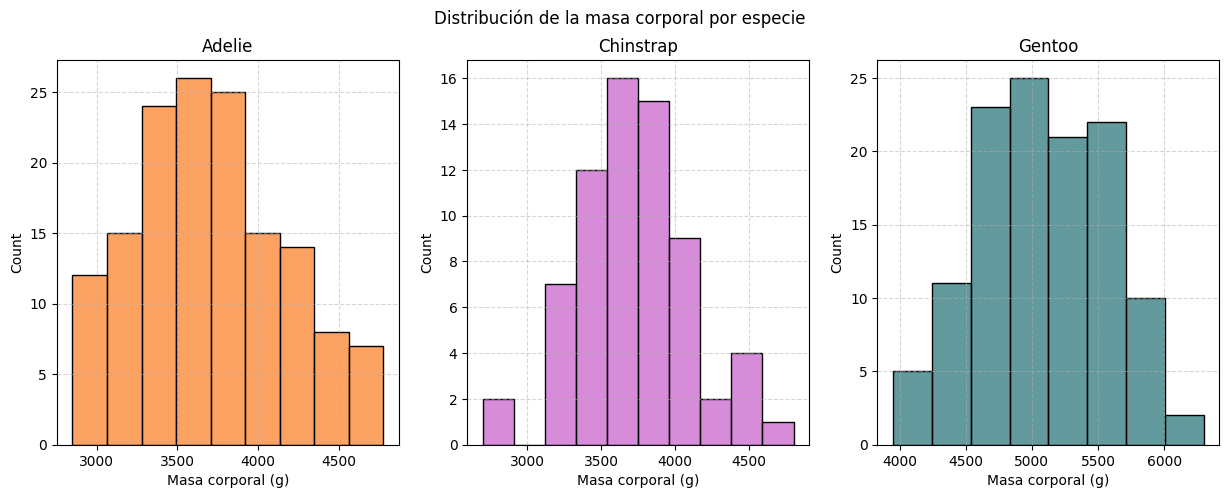

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i in range(len(df['species'].unique())):

    specie = df['species'].unique()[i]
    
    sns.histplot(data=df[df['species'] == specie], x='body_mass_g', ax=axes[i], color=penguin_palette[specie], alpha=0.7)
    axes[i].set_title(f'{specie}')
    axes[i].set_xlabel('Masa corporal (g)')
    axes[i].grid(True, alpha=0.5, linestyle='--')
plt.suptitle('Distribución de la masa corporal por especie')
plt.show()

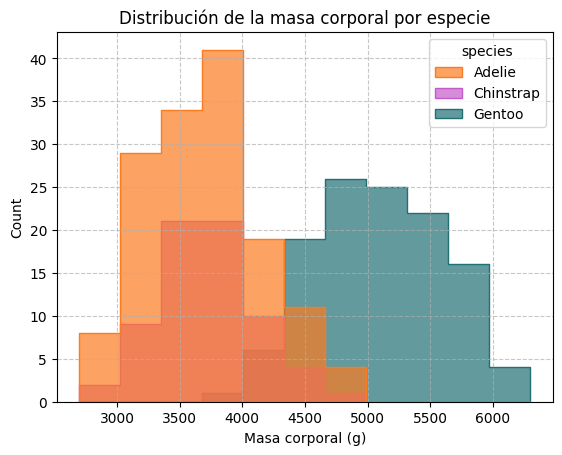

In [88]:
sns.histplot(data=df, x='body_mass_g', hue='species', palette=penguin_palette, alpha=0.7, element='step')
plt.grid(True, alpha=0.7, linestyle='--')
plt.xlabel('Masa corporal (g)')
plt.title('Distribución de la masa corporal por especie')
plt.show()

8. Describa la distribucion con ayuda de la media, desviacion estandard

La distribución de la masa corporal por especie es aproximadamente normal para cada grupo, como se observa en las gráficas.

- **Adelie**: Tiene una media de masa corporal de aproximadamente **3700.66 gramos** y una desviación estándar de **458.57 gramos**.
- **Chinstrap**: Presenta una media de **3733.09 gramos** y una desviación estándar de **384.34 gramos**.
- **Gentoo**: Es la especie con mayor masa corporal, con una media de **5076.02 gramos** y una desviación estándar de **504.12 gramos**.

En resumen, los pingüinos Gentoo son los más pesados y también muestran una mayor dispersión en su masa corporal. Adelie y Chinstrap tienen medias similares, pero los Adelie presentan una variabilidad ligeramente mayor.




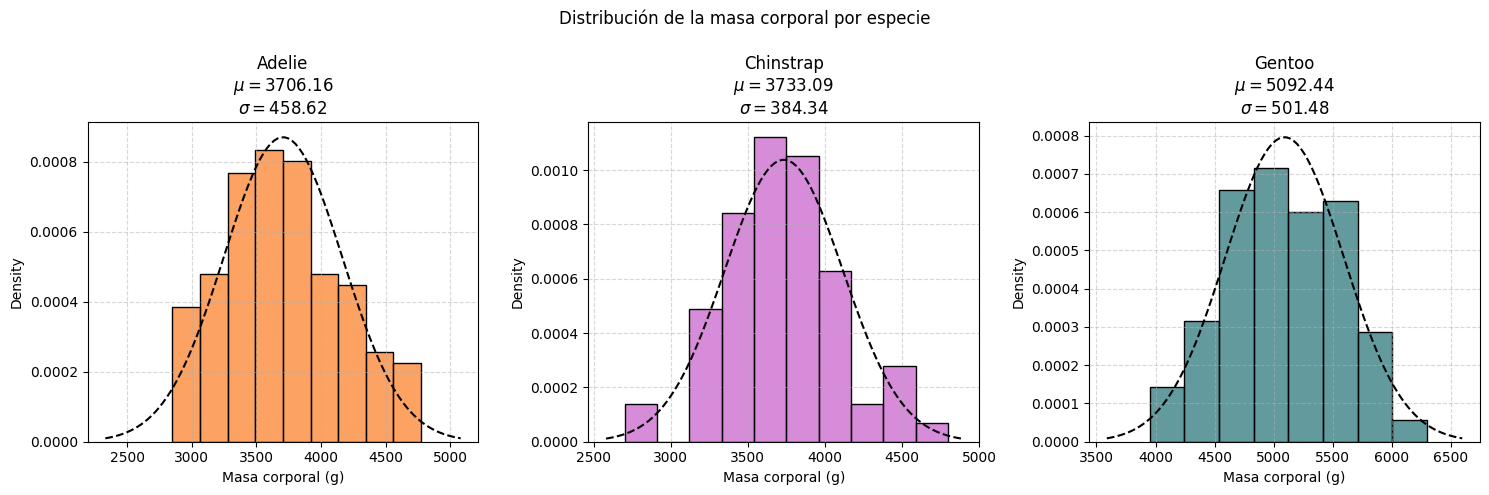

In [89]:
from scipy.stats import norm

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i in range(len(df['species'].unique())):

    specie = df['species'].unique()[i]
    
    sns.histplot(data=df[df['species'] == specie], x='body_mass_g', ax=axes[i], color=penguin_palette[specie], alpha=0.7, stat='density')
    axes[i].set_xlabel('Masa corporal (g)')
    axes[i].grid(True, alpha=0.5, linestyle='--')

    data = df[df['species'] == specie]
    mean = data['body_mass_g'].mean()
    std = data['body_mass_g'].std()

    axes[i].set_title(rf'{specie}' + '\n' + rf'$\mu={mean :.2f}$' + '\n' + rf'$\sigma={std :.2f}$')
    # Superponer normal
    x = np.linspace(mean - 3*std, mean + 3*std, 100)
    y = norm.pdf(x, mean, std) 
    axes[i].plot(x, y, color='black', linestyle='--')

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.suptitle('Distribución de la masa corporal por especie')
plt.show()

9. ¿Cuál es la diferencia en masa corporal promedio y desviacion estandard entre machos y hembras?
- Hembras: media ≈ 3862.27 g, desviación estándar ≈ 666.17 g  
- Machos: media ≈ 4545.68 g, desviación estándar ≈ 787.63 g  

Los machos tienden a ser más pesados que las hembras y presentan una mayor dispersión en la masa corporal, valdría la pena hacer un filtrado de sexo por especie.



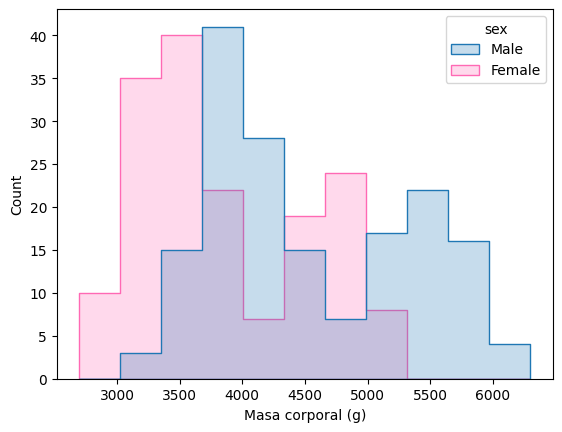

In [90]:
sns.histplot(data=df, x='body_mass_g', hue='sex', palette=sex_pallete, element='step')
plt.xlabel('Masa corporal (g)')
plt.show()

In [91]:
df.groupby('sex')['body_mass_g'].agg(['mean', 'std'])

,mean,std
sex,,
Female,3862.272727,666.172050
Male,4545.684524,787.628884


10. ¿Cuál es la media y la desviación estándar de la longitud de la aleta de los pingüinos por especie?

- Adelie: media ≈ 190.1 mm, desviación estándar ≈ 6.5 mm.
- Chinstrap: media ≈ 195.8 mm, desviación estándar ≈ 7.1 mm.
- Gentoo: media ≈ 217.2 mm, desviación estándar ≈ 6.5 mm.

Nota: Los valores se obtienen con `df.groupby('species')["flipper_length_mm"].agg(['mean','std'])` (celda 31).

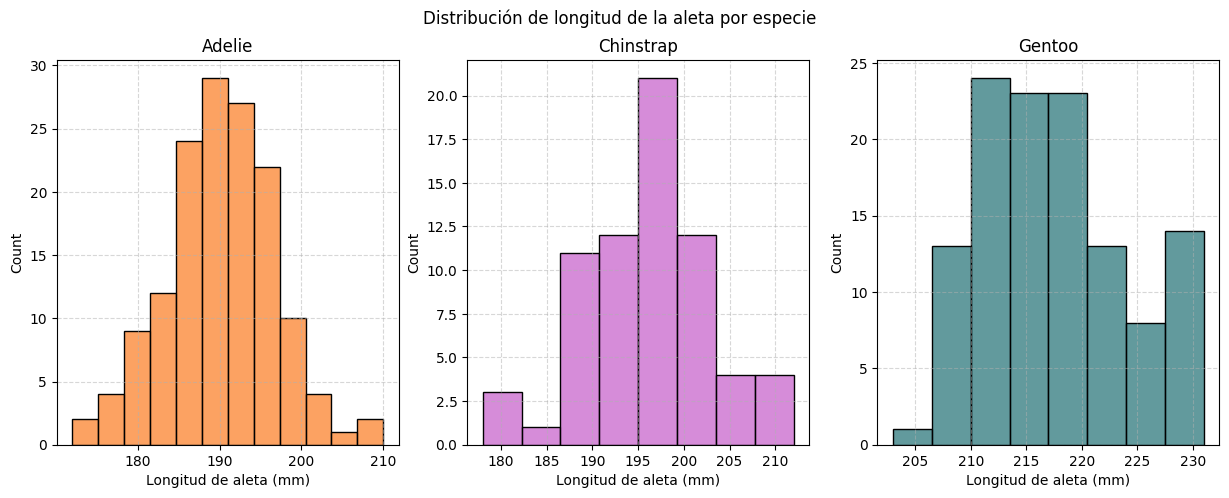

In [92]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i in range(len(df['species'].unique())):

    specie = df['species'].unique()[i]
    
    sns.histplot(data=df[df['species'] == specie], x='flipper_length_mm', ax=axes[i], color=penguin_palette[specie], alpha=0.7)
    axes[i].set_title(f'{specie}')
    axes[i].set_xlabel('Longitud de aleta (mm)')
    axes[i].grid(True, alpha=0.5, linestyle='--')
plt.suptitle('Distribución de longitud de la aleta por especie')
plt.show()

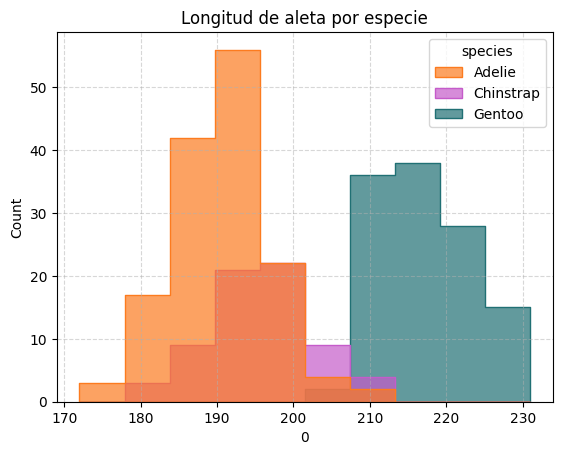

In [93]:
sns.histplot(data=df, x='flipper_length_mm', hue='species', palette=penguin_palette, alpha=0.7, element='step')
plt.grid(True, alpha=0.5, linestyle='--')
plt.xlabel(0)
plt.title('Longitud de aleta por especie')
plt.show()

In [94]:
df.groupby('species')['flipper_length_mm'].agg(['mean', 'std'])


,mean,std
species,,
Adelie,190.102740,6.521825
Chinstrap,195.823529,7.131894
Gentoo,217.235294,6.585431


11. ¿Cuál es la longitud mínima y máxima de la aleta entre las tres especies de pingüinos?

- Mínima: 172 mm
- Máxima: 231 mm

Se verificó con la celda 34 filtrando los extremos de `flipper_length_mm`. 

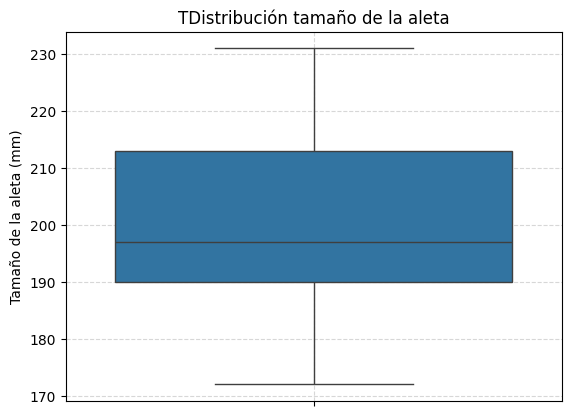

In [95]:
sns.boxplot(data=df, y='flipper_length_mm')
# plt.xlabel('Especie')
plt.ylabel('Tamaño de la aleta (mm)')
plt.title('TDistribución tamaño de la aleta')
plt.grid(True, alpha=0.5, linestyle='--')
plt.show()

In [96]:
df[(df['flipper_length_mm'] == df['flipper_length_mm'].min()) | (df['flipper_length_mm'] == df['flipper_length_mm'].max())]['flipper_length_mm']

28     172.0
283    231.0
Name: flipper_length_mm, dtype: float64

12. ¿Cómo varía la longitud del pico entre las diferentes especies de pingüinos en las distintas islas?

- En Biscoe predominan Gentoo con picos más largos; Adelie en Biscoe muestra picos más cortos.
- En Dream, Adelie y Chinstrap coexisten; Chinstrap tiende a picos más largos que Adelie.
- En Torgersen hay principalmente Adelie, con picos más cortos comparativamente.

Esto se aprecia en los boxplots por isla (celda 36) y en los descriptivos por `island`×`species` (celda 37).

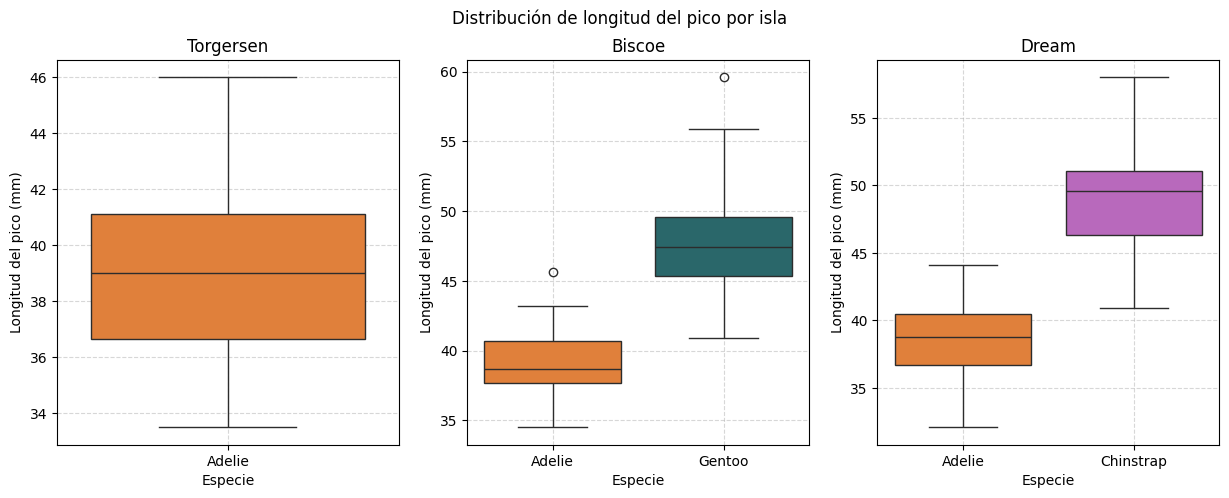

In [97]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))


for i in range(len(df['island'].unique())):

    island = df['island'].unique()[i]
    
    sns.boxplot(data=df[df['island'] == island], x='species', y='bill_length_mm', ax=axes[i], hue='species', palette=penguin_palette)
    axes[i].set_title(f'{island}')
    axes[i].set_ylabel('Longitud del pico (mm)')
    axes[i].set_xlabel('Especie')
    axes[i].grid(True, alpha=0.5, linestyle='--')
    
plt.suptitle('Distribución de longitud del pico por isla')
plt.show()

In [98]:
df.groupby(['island', 'species'])['bill_length_mm'].describe()

count       mean       std   min     25%    50%     75%  \
island    species                                                              
Biscoe    Adelie      44.0  38.975000  2.480916  34.5  37.675  38.70  40.700   
          Gentoo     119.0  47.568067  3.106116  40.9  45.350  47.40  49.600   
Dream     Adelie      55.0  38.520000  2.484276  32.1  36.700  38.80  40.450   
          Chinstrap   68.0  48.833824  3.339256  40.9  46.350  49.55  51.075   
Torgersen Adelie      47.0  39.038298  3.028097  33.5  36.650  39.00  41.100   

                      max  
island    species          
Biscoe    Adelie     45.6  
          Gentoo     59.6  
Dream     Adelie     44.1  
          Chinstrap  58.0  
Torgersen Adelie     46.0

13. ¿Cuál es la isla con la mayor variación en la longitud del pico entre las tres especies de pingüinos?

- Biscoe muestra mayor variación total en longitudes de pico, impulsada por la presencia de Gentoo (picos largos) y Adelie (picos más cortos).
- Dream presenta variación intermedia con Adelie y Chinstrap.
- Torgersen, con mayoría de Adelie, exhibe menor variación.

Esto se observa en las distribuciones por isla (celda 39). Para cuantificar, puede compararse el `std` de `bill_length_mm` por isla.

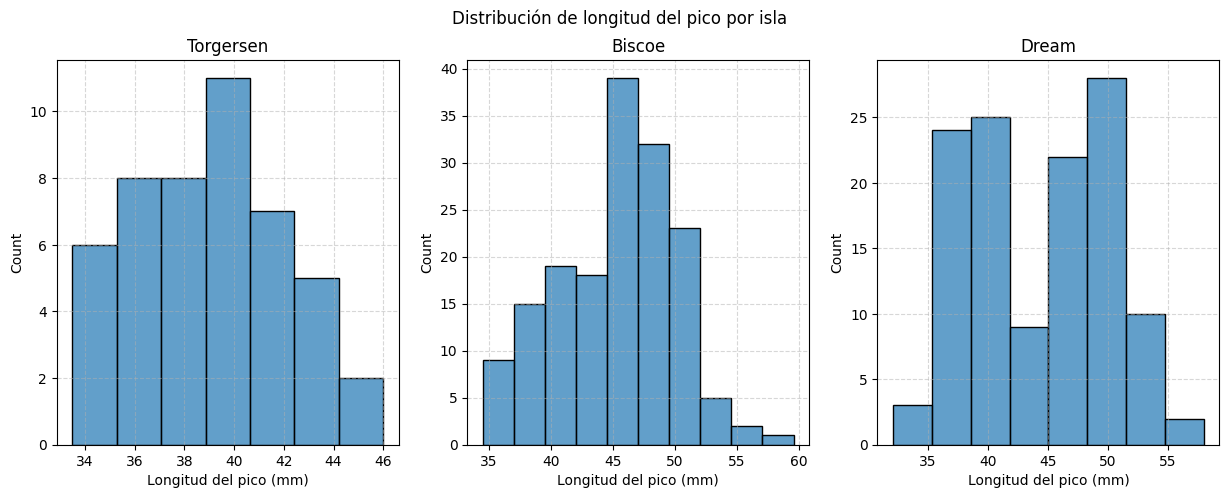

In [99]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i in range(len(df['island'].unique())):

    isla = df['island'].unique()[i]
    
    sns.histplot(data=df[df['island'] == isla], x='bill_length_mm', ax=axes[i], alpha=0.7)
    axes[i].set_title(f'{isla}')
    axes[i].set_xlabel('Longitud del pico (mm)')
    axes[i].grid(True, alpha=0.5, linestyle='--')
    
plt.suptitle('Distribución de longitud del pico por isla')
plt.show()

In [100]:
df.groupby('species')['bill_length_mm'].agg(['std'])

,std
species,
Adelie,2.662597
Chinstrap,3.339256
Gentoo,3.106116


## Relación entre caracteristicas de los pingüinos






14. ¿Cuál es la relación entre la longitud del pico y la masa corporal de los pingüinos? ¿Cambia esa relación si se mira por especie? Utilice diagramas de dispersión para visualizarlos.

- En conjunto se observa relación positiva: picos más largos tienden a asociarse con mayor masa corporal.
- Por especie, la pendiente varía: Gentoo muestra la relación más fuerte, seguida de Adelie y Chinstrap (consistente con las correlaciones impresas en la celda 45).

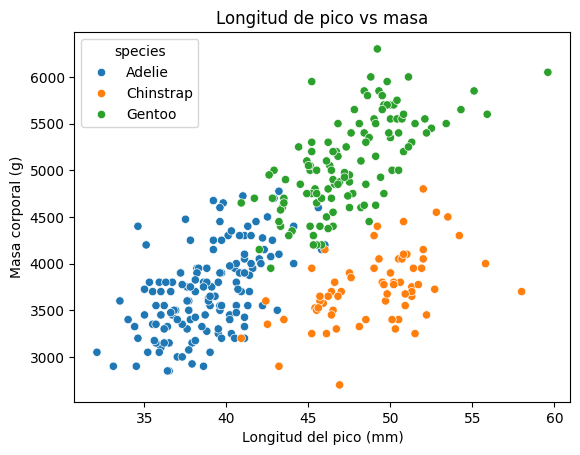

In [101]:
sns.scatterplot(data=df, x='bill_length_mm', y='body_mass_g', hue='species')
plt.xlabel('Longitud del pico (mm)')
plt.ylabel('Masa corporal (g)')
plt.title('Longitud de pico vs masa')
plt.show()

15. ¿Existe una correlación significativa entre la longitud del pico y la masa corporal en las diferentes especies de pingüinos?

- La longitud del pico y la masa corporal presentan una correlación moderada - alta. La especie que presenta una correlación más fuerte es Gentoo 


In [102]:
# Correlación por especie
for specie in df['species'].unique():
    species_data = df[df['species'] == specie]
    correlation = species_data['bill_length_mm'].corr(species_data['body_mass_g'])
    print(f"{specie}: {correlation:.3f}")


Adelie: 0.544
Chinstrap: 0.514
Gentoo: 0.667


16. ¿Cuál es la relación entre el sexo y la longitud de la aleta en los pingüinos por especie?

Existe una tendencia a que en promedio la longitud de la aleta de los pinguinos machos sea mayor que la de las hembras

In [103]:
# import matplotlib.gridspec as gridspec

# fig = plt.figure(figsize=(12, 8))
# gs = gridspec.GridSpec(2, 3, figure=fig, height_ratios=[1, 1]) # Crear GridSpec de 2 filas x 3 columnas
# gs.update(hspace=0.4)
    
# sns.histplot(data=df[df['species'] == specie], x='flipper_length_mm', ax=axes[i], color=penguin_palette[specie], alpha=0.7)
# axes[i].set_title(f'{specie}')
# axes[i].set_xlabel('Longitud de aleta (mm)')
# axes[i].grid(True, alpha=0.5, linestyle='--')
# # ax_title1.set_facecolor("#1f77b4")  

# for i in range(len(df['species'].unique())):

#     specie = df['species'].unique()[i]
#     axis = fig.add_subplot(gs[0, i])
#     sns.histplot(data=df[(df['sex'] == 'Male') & (df['species'] == specie)], x='flipper_length_mm', ax=axis, color=penguin_palette[specie], alpha=0.7)
#     axis.set_title(f'{specie}')
#     axis.set_xlabel('Longitud de la aleta (mm)')
#     axis.grid(True, alpha=0.5, linestyle='--')


# # -- Female --
# ax_title1 = fig.add_subplot(gs[1, :])
# ax_title1.axis('off')  # Oculta el eje
# ax_title1.set_title("Hembra", fontsize=14, loc='center', y=1.1)
# # ax_title1.set_facecolor("#1f77b4")  

# for i in range(len(df['species'].unique())):

#     specie = df['species'].unique()[i]
#     axis = fig.add_subplot(gs[1, i])
#     sns.histplot(data=df[(df['sex'] == 'Female') & (df['species'] == specie)], x='flipper_length_mm', ax=axis, color=penguin_palette[specie], alpha=0.7)
#     axis.set_title(f'{specie}')
#     axis.set_xlabel('Longitud de la aleta (mm)')
#     axis.grid(True, alpha=0.5, linestyle='--')

# # plt.subplots_adjust(left=0.5)

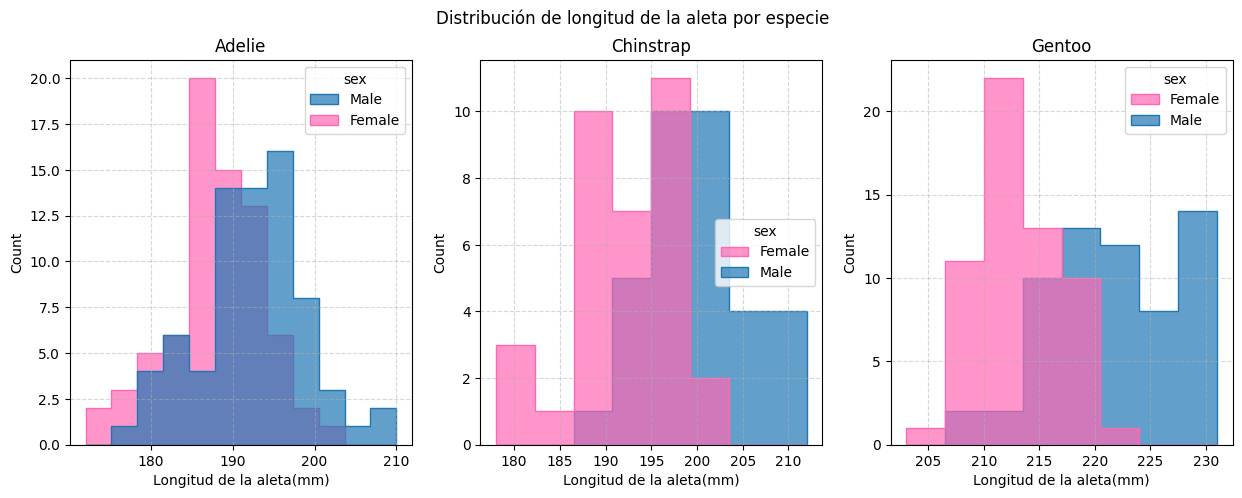

In [104]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i in range(len(df['species'].unique())):

    specie = df['species'].unique()[i]
    
    sns.histplot(data=df[df['species'] == specie], x='flipper_length_mm', ax=axes[i], alpha=0.7, hue='sex', palette=sex_pallete, element='step')
    axes[i].set_title(f'{specie}')
    axes[i].set_xlabel('Longitud de la aleta(mm)')
    axes[i].grid(True, alpha=0.5, linestyle='--')
    
plt.suptitle('Distribución de longitud de la aleta por especie')
plt.show()

## Test de hipótesis

17. Escoja una de las tendencias que haya observado en la cual haya una correlación entre las variables y ahora con un test de hipótesis determine si esta correlación puede ser explicada por aleatoriedad. Para esta pregunta puede usar las relaciones del libro "Probabilidad y Estadistica" de Marques de Cantu sección 12.6 donde hay un ejemplo 12.8 que les guia como usar las expresiones y hacer las conclusiones. 

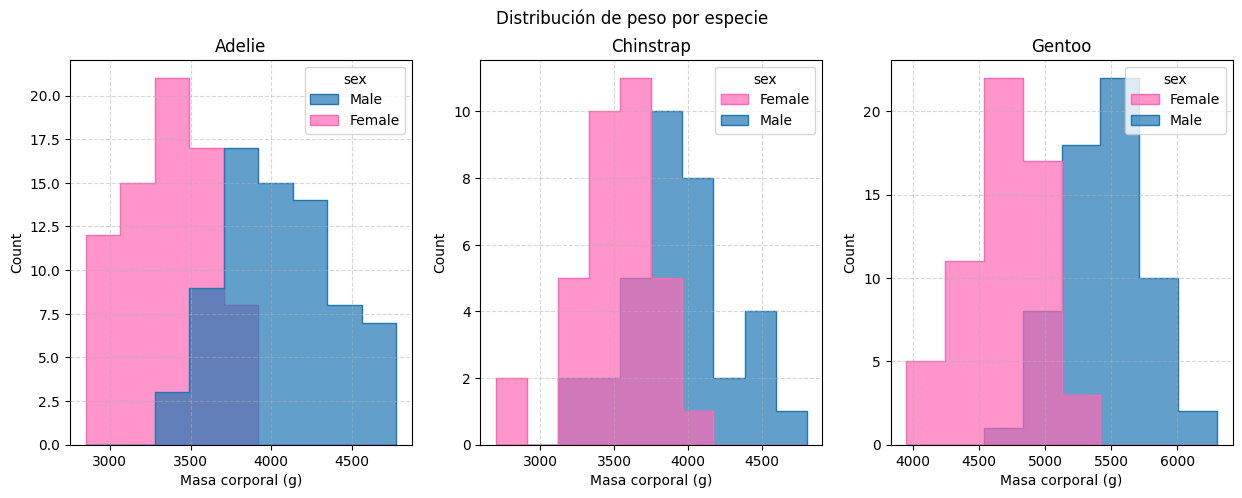

In [105]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i in range(len(df['species'].unique())):

    specie = df['species'].unique()[i]
    
    sns.histplot(data=df[df['species'] == specie], x='body_mass_g', ax=axes[i], alpha=0.7, hue='sex', palette=sex_pallete, element='step')
    axes[i].set_title(f'{specie}')
    axes[i].set_xlabel('Masa corporal (g)')
    axes[i].grid(True, alpha=0.5, linestyle='--')
    
plt.suptitle('Distribución de peso por especie')
plt.show()

En cada una de las especies de pinguino, existe una correlación entre el sexo del individuo y su masa corporal. Para ello proponemos las siguientes hipótesis:

**Hipotesis nula ($H_0$)**: En la población (segmentado por especie), la distribución de la masa corporal no depende del sexo del individuo. La diferencia en la muestra se debe al azar.

**Hipotesis alternativa ($H_a$)**: En la población, los pinguinos machos tienen, en promedio,  mayor masa corporal que los pinguinos hembra.


In [106]:
medias = df.groupby(['species', 'sex'])['body_mass_g'].mean().unstack()
medias['diff'] = medias['Male'] - medias['Female']
medias['diff']

species
Adelie       674.657534
Chinstrap    411.764706
Gentoo       805.094686
Name: diff, dtype: float64

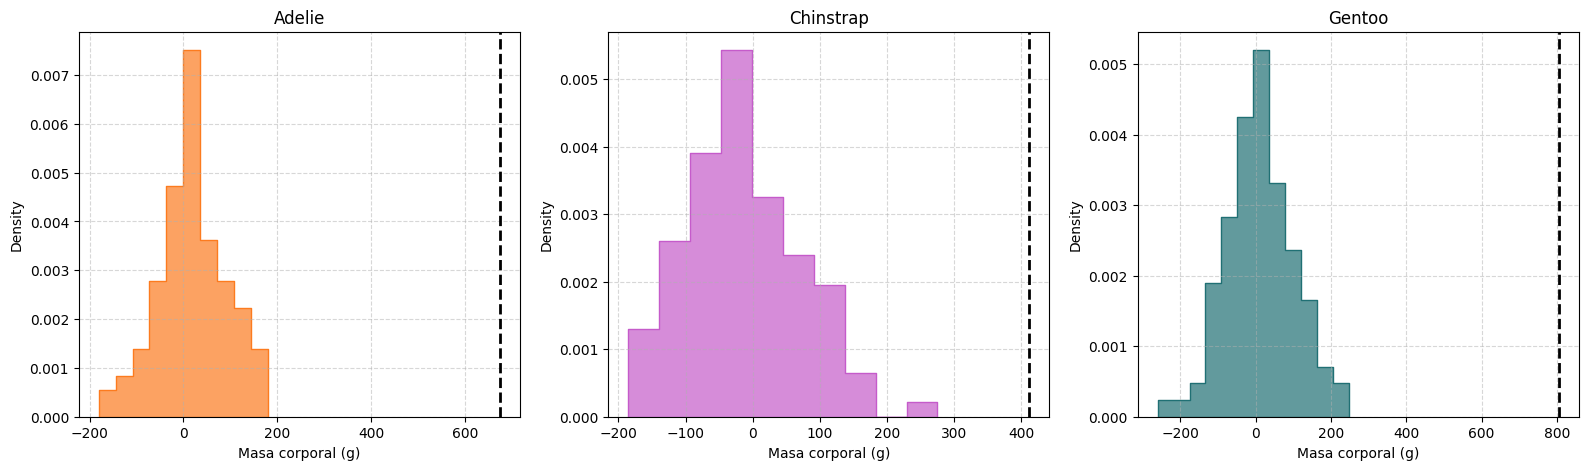

In [107]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
data = df[['species', 'sex', 'body_mass_g']]

 
for i in range(len(data['species'].unique())):
    # -- Filtro por especies --
    specie = data['species'].unique()[i]
    data_by_specie = data[data['species'] == specie].drop(columns='species')

    diff = []
    
    for _ in range(100):
        # Generamos un remuestreo Bootstrap para cada especie
        shuffled_boddy_mass = data_by_specie.sample(frac=1, replace=False).reset_index(drop=True)
        shuffled_data = data_by_specie.copy().reset_index(drop=True)
        shuffled_data['body_mass_g'] = shuffled_boddy_mass['body_mass_g']

        # Añadimos la diferencia entre las medias
        diff.append(shuffled_data[shuffled_data['sex']=='Male']['body_mass_g'].mean()
             - shuffled_data[shuffled_data['sex']=='Female']['body_mass_g'].mean())

    # -- Histograma -- 
    sns.histplot(x=diff, ax=axes[i], color=penguin_palette[specie], alpha=0.7, stat='density', element='step')
    axes[i].set_title(f'{specie}')
    axes[i].set_xlabel('Masa corporal (g)')
    axes[i].grid(True, alpha=0.5, linestyle='--')
    
    # -- Diferencia real entre las medias --
    axes[i].axvline(medias['diff'][specie], color='black', linestyle='dashed', linewidth=2, label="Diferencia Observada")

plt.subplots_adjust(left=-0.1)
# sns.histplot(x=diff)}

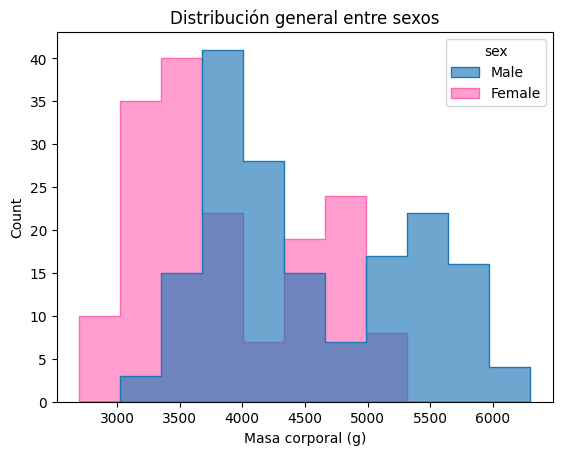

In [108]:
sns.histplot(data=df, x='body_mass_g', hue='sex', palette=sex_pallete, element='step', alpha=0.65)
plt.xlabel('Masa corporal (g)')
plt.title('Distribución general entre sexos')
plt.show()

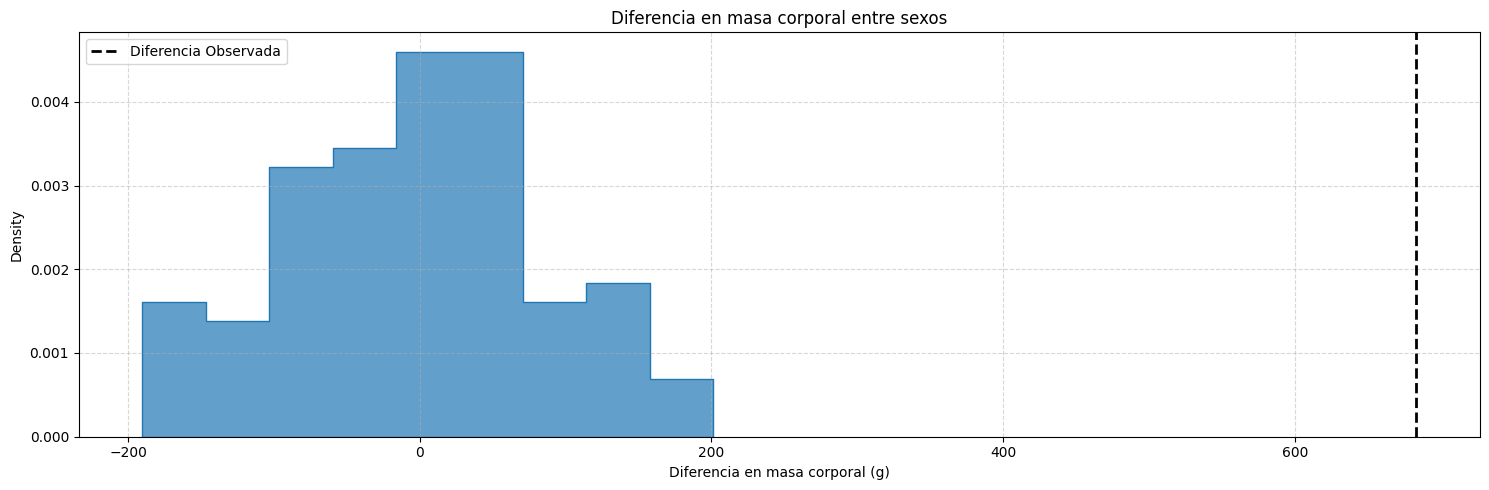

In [109]:
fig, ax = plt.subplots(figsize=(15, 5))
data = df[['sex', 'body_mass_g']]

diff = []

for _ in range(100):
    # Generamos un remuestreo Bootstrap para todos los datos
    shuffled_body_mass = data.sample(frac=1, replace=False).reset_index(drop=True)
    shuffled_data = data.copy().reset_index(drop=True)
    shuffled_data['body_mass_g'] = shuffled_body_mass['body_mass_g']

    # Añadimos la diferencia entre las medias
    diff.append(shuffled_data[shuffled_data['sex']=='Male']['body_mass_g'].mean()
         - shuffled_data[shuffled_data['sex']=='Female']['body_mass_g'].mean())

# -- Histograma -- 
sns.histplot(x=diff, ax=ax, alpha=0.7, stat='density', element='step')
ax.set_title('Diferencia en masa corporal entre sexos')
ax.set_xlabel('Diferencia en masa corporal (g)')
ax.grid(True, alpha=0.5, linestyle='--')

# -- Diferencia real entre las medias --
real_diff = data[data['sex']=='Male']['body_mass_g'].mean() - data[data['sex']=='Female']['body_mass_g'].mean()
ax.axvline(real_diff, color='black', linestyle='dashed', linewidth=2, label="Diferencia Observada")
ax.legend()

plt.tight_layout()

## Análisis Estadístico: Prueba t

Como para todas las especies parece existir una correlación, hagamos un análisis más robusto incluyendo las 3 especies
Para determinar si existe una diferencia estadísticamente significativa en la masa corporal entre machos y hembras, realizamos una prueba(t-test con varianzas desiguales).

### Hipótesis:
- **H₀ (Hipótesis nula)**: No existe diferencia en la media de la masa corporal entre machos y hembras
- **Hₐ (Hipótesis alternativa)**: Los machos tienen, en promedio, mayor masa corporal que las hembras


In [110]:
from scipy import stats
import numpy as np

# Separar los datos por sexo
male_mass = df[df['sex'] == 'Male']['body_mass_g'].dropna()
female_mass = df[df['sex'] == 'Female']['body_mass_g'].dropna()

print("=== ESTADÍSTICOS DESCRIPTIVOS ===")
print(f"Machos (n={len(male_mass)}):")
print(f"  Media: {male_mass.mean():.2f} g")
print(f"  Desviación estándar: {male_mass.std():.2f} g")
print(f"  Error estándar: {male_mass.std()/np.sqrt(len(male_mass)):.2f} g")

print(f"\nHembras (n={len(female_mass)}):")
print(f"  Media: {female_mass.mean():.2f} g")
print(f"  Desviación estándar: {female_mass.std():.2f} g")
print(f"  Error estándar: {female_mass.std()/np.sqrt(len(female_mass)):.2f} g")

print(f"\nDiferencia observada: {male_mass.mean() - female_mass.mean():.2f} g")


=== ESTADÍSTICOS DESCRIPTIVOS ===
Machos (n=168):
  Media: 4545.68 g
  Desviación estándar: 787.63 g
  Error estándar: 60.77 g

Hembras (n=165):
  Media: 3862.27 g
  Desviación estándar: 666.17 g
  Error estándar: 51.86 g

Diferencia observada: 683.41 g


In [116]:
# Realizar la prueba t de Welch (varianzas desiguales)
t_stat, p_value_bilateral = stats.ttest_ind(male_mass, female_mass, equal_var=False)

# Calcular el p-valor unilateral (machos > hembras)
# Para prueba unilateral, dividimos el p-valor bilateral por 2
p_value_unilateral = p_value_bilateral / 2

print("=== RESULTADOS DE LA PRUEBA ===")
print(f"Estadístico t: {t_stat:.4f}")
print(f"P-valor bilateral: {p_value_bilateral:.6f}")
print(f"P-valor unilateral (machos > hembras): {p_value_unilateral:.6f}")

# Grados de libertad aproximados (fórmula de Welch-Satterthwaite)
n1, n2 = len(male_mass), len(female_mass)
s1, s2 = male_mass.std(), female_mass.std()
df_welch = (s1**2/n1 + s2**2/n2)**2 / ((s1**2/n1)**2/(n1-1) + (s2**2/n2)**2/(n2-1))
print(f"Grados de libertad (Welch): {df_welch:.2f}")

# Nivel de significancia
alpha = 0.05
print(f"\n=== INTERPRETACIÓN (α = {alpha}) ===")
if p_value_unilateral < alpha:
    print(f"RECHAZAMOS H₀: p = {p_value_unilateral:.6f} < α = {alpha}")
    print("   Conclusión: Los machos tienen significativamente mayor masa corporal que las hembras")
else:
    print(f"NO RECHAZAMOS H₀: p = {p_value_unilateral:.6f} ≥ α = {alpha}")
    print("   Conclusión: No hay evidencia suficiente para afirmar que los machos son más pesados")


=== RESULTADOS DE LA PRUEBA ===
Estadístico t: 8.5545
P-valor bilateral: 0.000000
P-valor unilateral (machos > hembras): 0.000000
Grados de libertad (Welch): 323.90

=== INTERPRETACIÓN (α = 0.05) ===
RECHAZAMOS H₀: p = 0.000000 < α = 0.05
   Conclusión: Los machos tienen significativamente mayor masa corporal que las hembras


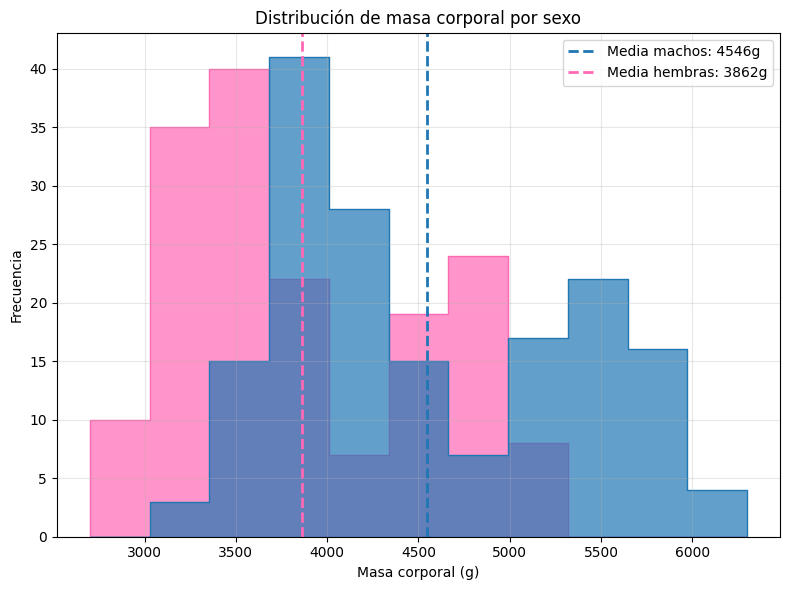

In [118]:
# Crear gráfica de distribución en un solo eje
fig, ax = plt.subplots(figsize=(8, 6))

# Histograma superpuesto
sns.histplot(data=df, x='body_mass_g', hue='sex', palette=sex_pallete, 
             alpha=0.7, element='step', ax=ax)
ax.set_xlabel('Masa corporal (g)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de masa corporal por sexo')
ax.grid(True, alpha=0.3)

# Agregar líneas de media
ax.axvline(male_mass.mean(), color=sex_pallete['Male'], linestyle='--', 
           linewidth=2, label=f'Media machos: {male_mass.mean():.0f}g')
ax.axvline(female_mass.mean(), color=sex_pallete['Female'], linestyle='--', 
           linewidth=2, label=f'Media hembras: {female_mass.mean():.0f}g')
ax.legend()

plt.tight_layout()
plt.show()




Este análisis complementa el análisis de bootstrap realizado anteriormente, proporcionando una evaluación estadística formal de la diferencia observada entre los grupos. La prueba t con varianzas desiguales es especialmente apropiada cuando las varianzas de los grupos son desiguales, como es el caso en este dataset.
